# K04_00 Lineare Regression Ringbeispiel

Letzter Update am 23. Mai 2026

# Lineare Regression anhand eines einfachen Beispieles

Modell: `LinearRegression()`

Daten: `koerpergroesse vs. ringfingerumfang`

Metrik: `r2_score` (Bestimmtheitsmaß R²)

> **Wichtig:** Das Bestimmtheitsmaß R² wird immer auf den **Testdaten** berechnet,
> nicht auf den Trainingsdaten. Sonst würden wir messen, wie gut das Modell
> auswendig gelernt hat – nicht, wie gut es generalisiert.


# Daten visualisieren

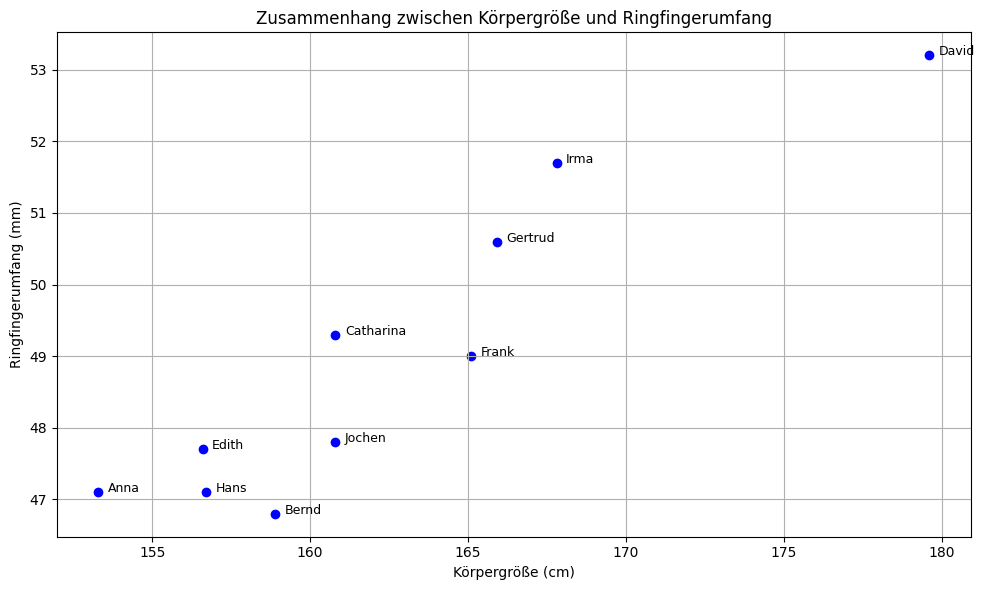

In [6]:
import matplotlib.pyplot as plt

# Daten
personen = ["Anna", "Bernd", "Catharina", "David", "Edith",
            "Frank", "Gertrud", "Hans", "Irma", "Jochen"]
koerpergroesse = [153.3, 158.9, 160.8, 179.6, 156.6,
                  165.1, 165.9, 156.7, 167.8, 160.8]
ringfingerumfang = [47.1, 46.8, 49.3, 53.2, 47.7,
                    49.0, 50.6, 47.1, 51.7, 47.8]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(koerpergroesse, ringfingerumfang, color='blue')

# mit Beschriftung
for i, name in enumerate(personen):
    plt.text(koerpergroesse[i] + 0.3, ringfingerumfang[i], name, fontsize=9)

plt.title("Zusammenhang zwischen Körpergröße und Ringfingerumfang")
plt.xlabel("Körpergröße (cm)")
plt.ylabel("Ringfingerumfang (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()


# Train/Test-Split

Bevor wir das Modell trainieren, teilen wir die Daten auf:

- **Trainingsdaten**: das Modell lernt darauf
- **Testdaten**: das Modell wird darauf bewertet – diese Daten sieht es beim Training nicht

Wir verwenden 80 % für das Training und 20 % für den Test.

> **Hinweis:** Bei nur 10 Datenpunkten ist ein Split statistisch wenig aussagekräftig.
> Wir führen ihn trotzdem durch, um den **Workflow** korrekt zu zeigen.


In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

# Daten in Feature-Matrix und Zielvektor umwandeln
X = np.array(koerpergroesse).reshape(-1, 1)  # (10,) → (10, 1): scikit-learn braucht 2D-Arrays
                                              # -1 bedeutet: Anzahl Zeilen automatisch berechnen
y = np.array(ringfingerumfang)

# 80% Training, 20% Test – random_state sorgt für Reproduzierbarkeit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # Hinweis: stratify ist bei Regression nicht verfügbar (y ist kontinuierlich)
)

print(f"Gesamtdaten:    {len(X)} Personen")
print(f"Trainingsdaten: {len(X_train)} Personen (80%)")
print(f"Testdaten:      {len(X_test)} Personen (20%)")


Gesamtdaten:    10 Personen
Trainingsdaten: 8 Personen (80%)
Testdaten:      2 Personen (20%)


# Lineare Regression durchführen

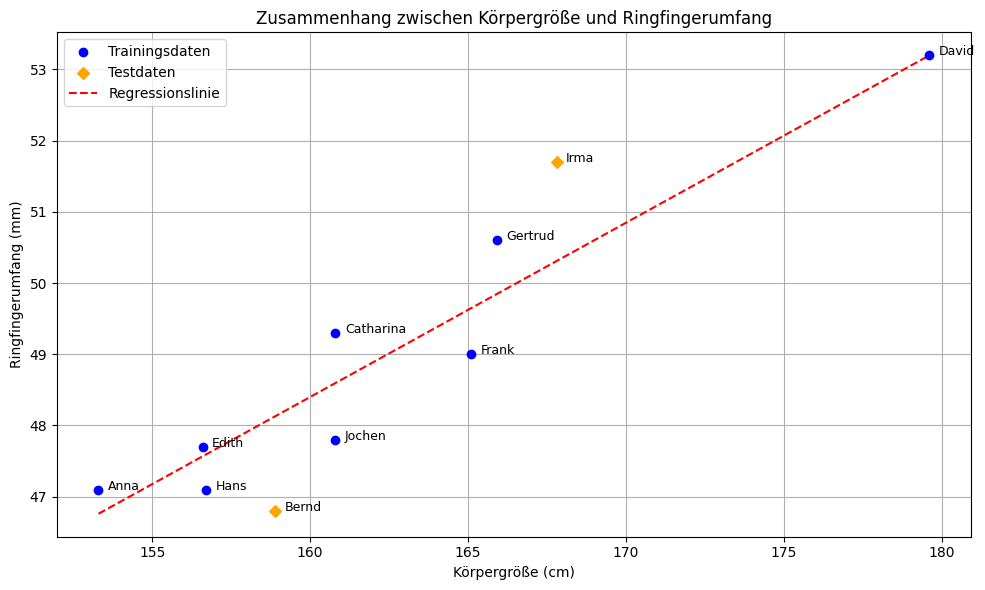

In [8]:
from sklearn.linear_model import LinearRegression

# Modell erstellen und auf TRAININGSDATEN trainieren
modell = LinearRegression()
modell.fit(X_train, y_train)   # nur Trainingsdaten – Testdaten bleiben unberührt

# Vorhersagewerte für die Regressionslinie (feines Raster für glatte Kurve)
x_linspace = np.linspace(min(koerpergroesse), max(koerpergroesse), 100).reshape(-1, 1)
y_pred_linie = modell.predict(x_linspace)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue',   label='Trainingsdaten', zorder=3)
plt.scatter(X_test,  y_test,  color='orange', label='Testdaten',      zorder=3, marker='D')

# Namen für alle Punkte einfügen
for i, name in enumerate(personen):
    plt.text(koerpergroesse[i] + 0.3, ringfingerumfang[i], name, fontsize=9)

# Regressionslinie
plt.plot(x_linspace, y_pred_linie, color='red', linestyle='--', label='Regressionslinie')

plt.title("Zusammenhang zwischen Körpergröße und Ringfingerumfang")
plt.xlabel("Körpergröße (cm)")
plt.ylabel("Ringfingerumfang (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Modell Koeffizienten ausgeben

In [9]:
# Koeffizienten
a = modell.coef_[0]
b = modell.intercept_

print(f"y = {a:.4f} * x + {b:.4f}")


y = 0.2448 * x + 9.2262


# Bestimmtheitsmaß R² berechnen

R² ("R-Quadrat") misst, wie gut das Modell die Streuung der Zielwerte erklärt:

| R²-Wert | Interpretation |
|:---:|---|
| 1.0 | Modell erklärt die Daten perfekt |
| 0.8 | Modell erklärt 80 % der Streuung |
| 0.0 | Modell ist nicht besser als der Mittelwert |
| < 0 | Modell ist schlechter als der Mittelwert |

> **Wichtig:** Wir berechnen R² auf den **Testdaten** – nur so erhalten wir
> eine ehrliche Schätzung, wie gut das Modell auf neuen, ungesehenen Daten funktioniert.


In [10]:
from sklearn.metrics import r2_score

# Vorhersage auf den TESTDATEN
y_pred_test = modell.predict(X_test)

# R² auf Testdaten – das ist die ehrliche Schätzung der Modellgüte
r2 = r2_score(y_test, y_pred_test)
print(f"Bestimmtheitsmaß (R²) auf Testdaten: {r2:.4f}")

# Zum Vergleich: R² auf Trainingsdaten (immer höher – warum?)
y_pred_train = modell.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"Bestimmtheitsmaß (R²) auf Trainingsdaten: {r2_train:.4f}")
print()
print("Merksatz: Der Test-R² ist die entscheidende Kennzahl.")
print("          Ein hohes Train-R² bei niedrigem Test-R² wäre ein Zeichen für Overfitting.")


Bestimmtheitsmaß (R²) auf Testdaten: 0.6915
Bestimmtheitsmaß (R²) auf Trainingsdaten: 0.9185

Merksatz: Der Test-R² ist die entscheidende Kennzahl.
          Ein hohes Train-R² bei niedrigem Test-R² wäre ein Zeichen für Overfitting.


# Lessons Learned

1. **Datenvisualisierung zur Mustererkennung**:  
Durch die Erstellung eines Scatter-Plots konnten wir den Zusammenhang zwischen
Körpergröße und Ringfingerumfang visuell erfassen. Dies ist ein erster wichtiger
Schritt, um Daten zu verstehen.

---

2. **Train/Test-Split**:  
Wir haben die Daten in Trainings- und Testdaten aufgeteilt. Das Modell lernt
ausschließlich auf den Trainingsdaten. Die Testdaten dienen der Bewertung –
sie simulieren neue, unbekannte Daten.

---

3. **Anwendung der linearen Regression**:  
Es wurde gezeigt, wie man ein lineares Regressionsmodell mit `scikit-learn` erstellt,
trainiert und für Vorhersagen verwendet.

---

4. **Bewertung der Modellgüte mit R²**:  
Das Bestimmtheitsmaß R² zeigt, wie gut das Modell die Streuung der Zielwerte
erklärt. Ein R² nahe 1 ist gut. Entscheidend ist der Wert auf den **Testdaten**,
nicht auf den Trainingsdaten.

---

**Merksatz:**  
R² auf Trainingsdaten lügt – R² auf Testdaten sagt die Wahrheit.
